In [2]:
!pip install -q pytorch-lightning transformers protobuf==4.25.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 5.7 MB/s eta 0:00:000:00:0100:01
ERROR: pip's dependency 

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import albumentations as A
import random
import wandb
import torch
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl 
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.model_checkpoint import ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import LearningRateMonitor
from transformers import AutoImageProcessor, ResNetForImageClassification
from torchmetrics import Accuracy, F1Score, Precision, Recall
from tqdm import tqdm
import warnings
device = ("cuda" if torch.cuda.is_available() else "cpu")
label2id = {'cat': 0, 'dog': 1}
id2label = {v: k for k, v in label2id.items()}

os.environ["WANDB_API_KEY"] = "YOUR API KEY"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)               # CPU
    torch.cuda.manual_seed(seed)          # GPU
    torch.cuda.manual_seed_all(seed)      # Multi-GPU (nếu có)

    # For deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [4]:
class CatDogDataset(Dataset): 
    def __init__(self, rootDir, label2id, transforms=None): 
        assert isinstance(rootDir, str)
        self.rootDir = rootDir
        self.label2id = label2id
        self.transforms = transforms
        subFolder = os.listdir(rootDir)
        if Path(os.path.join(rootDir, subFolder[0])).is_dir(): 
            self.list_images = []
            for folder in subFolder: 
                folder_path = os.path.join(rootDir, folder)
                for img in os.listdir(folder_path): 
                    img_path = os.path.join(folder_path, img)
                    self.list_images.append(img_path)
    def __len__(self): 
        return len(self.list_images)
    def __getitem__(self, idx): 
        image_id = self.list_images[idx]
        label_name = Path(image_id).parent.name
        label_id = self.label2id[label_name] 
        image = cv2.imread(image_id)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transforms: 
            augmented = self.transforms(image=image)
            image = augmented['image']
        return image, label_id

## Data Statistic

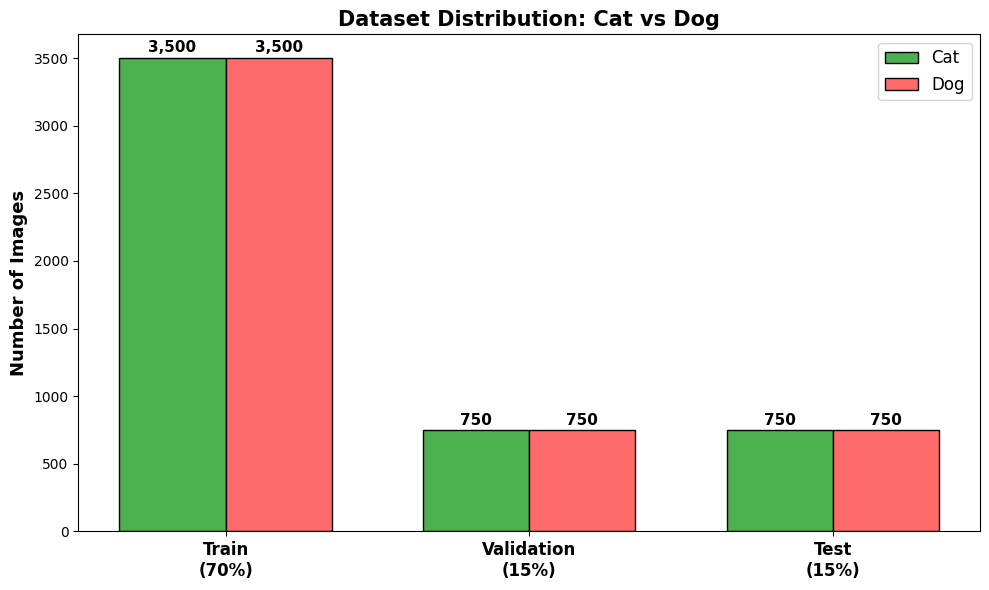

In [32]:
plt.figure(figsize=(10, 6))

train_cat = len(os.listdir("/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/train/cat"))
train_dog = len(os.listdir("/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/train/dog"))
val_cat = len(os.listdir("/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/val/cat"))
val_dog = len(os.listdir("/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/val/dog"))
test_cat = len(os.listdir("/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/test/cat"))
test_dog = len(os.listdir("/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/test/dog"))

# Color
cat_color = '#FF8C00'  # Orange 
dog_color = '#FF6B6B'   # Red

width = 0.35
x_positions = [0, 1, 2]

# Train: Cat and Dog 
plt.bar(x_positions[0] - width/2, train_cat, width, color=colors[0], edgecolor='black', linewidth=1)
plt.bar(x_positions[0] + width/2, train_dog, width, color=colors[1], edgecolor='black', linewidth=1)

# Validation: Cat and Dog
plt.bar(x_positions[1] - width/2, val_cat, width, color=colors[0], edgecolor='black', linewidth=1)
plt.bar(x_positions[1] + width/2, val_dog, width, color=colors[1], edgecolor='black', linewidth=1)

# Test: Cat and Dog
plt.bar(x_positions[2] - width/2, test_cat, width, color=colors[0], edgecolor='black', linewidth=1)
plt.bar(x_positions[2] + width/2, test_dog, width, color=colors[1], edgecolor='black', linewidth=1)

plt.text(x_positions[0] - width/2, train_cat + 20, f'{train_cat:,}', 
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
plt.text(x_positions[0] + width/2, train_dog + 20, f'{train_dog:,}', 
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

plt.text(x_positions[1] - width/2, val_cat + 15, f'{val_cat:,}', 
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
plt.text(x_positions[1] + width/2, val_dog + 15, f'{val_dog:,}', 
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

plt.text(x_positions[2] - width/2, test_cat + 15, f'{test_cat:,}', 
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
plt.text(x_positions[2] + width/2, test_dog + 15, f'{test_dog:,}', 
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

plt.ylabel('Number of Images', fontsize=13, fontweight='bold')
plt.title('Dataset Distribution: Cat vs Dog', fontsize=15, fontweight='bold')
plt.xticks(x_positions, ['Train\n(70%)', 'Validation\n(15%)', 'Test\n(15%)'], 
           fontweight='bold', fontsize=12)

legend_elements = [
    Patch(facecolor=colors[0], edgecolor='black', label='Cat'),
    Patch(facecolor=colors[1], edgecolor='black', label='Dog')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/cats_and_dogs_distribution.jpg')
plt.show()

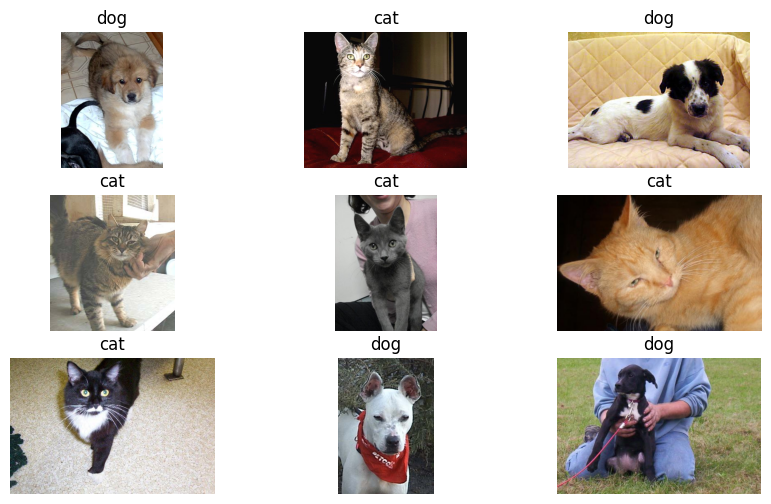

In [49]:
plt.figure(figsize=(10, 6))
train_data = CatDogDataset("/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/train", label2id=label2id)
numbers = random.sample(range(0, len(train_data)), k=9)
row, col = 3, 3
for i, n in enumerate(numbers): 
    example_image, example_label = train_data[n]
    plt.subplot(row, col, i + 1)
    plt.imshow(example_image)
    plt.title(f'{id2label[example_label]}')
    plt.axis('off')

plt.imshow(image)
plt.show()

## Data Augmenation

In [5]:
train_transforms = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    A.ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(256, 256),
    A.CenterCrop(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    A.ToTensorV2(),
])

In [6]:
train_dataset = CatDogDataset(rootDir='/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/train', 
                              label2id=label2id,
                              transforms=train_transforms)
val_dataset = CatDogDataset(rootDir='/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/val', 
                            label2id=label2id,
                            transforms=val_transforms)
test_dataset = CatDogDataset(rootDir='/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/test',
                             label2id=label2id,
                             transforms=val_transforms)

In [7]:
BATCH_SIZE = 64
train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
data = next(iter(train_dataloader))
print(f'Input image: {data[0].shape}')

Input image: torch.Size([64, 3, 224, 224])


## Setup Training

In [9]:
class ResNetFinetuner(pl.LightningModule):
    def __init__(self, id2label, label2id, train_dataloader=None, val_dataloader=None, 
                 lr=None, metrics_interval=100):
        super(ResNetFinetuner, self).__init__()
        self.save_hyperparameters(ignore=['train_dataloader', 'val_dataloader'])
        self.id2label = id2label
        self.label2id = label2id
        self.num_classes = len(id2label.keys())
        self.train_dl = train_dataloader
        self.val_dl = val_dataloader
        self.lr = lr
        self.metrics_interval = metrics_interval
        self.model = ResNetForImageClassification.from_pretrained("microsoft/resnet-18",
                                                                  num_labels=len(id2label.keys()),
                                                                  id2label=self.id2label, 
                                                                  label2id=self.label2id,
                                                                  ignore_mismatched_sizes=True)
        self._freeze_backbone()
        self.train_acc = Accuracy(task='multiclass', num_classes=self.num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=self.num_classes)
        self.val_f1 = F1Score(task='multiclass', num_classes=self.num_classes, average='macro')
        self.val_precision = Precision(task='multiclass', num_classes=self.num_classes, average='macro')
        self.val_recall = Recall(task='multiclass', num_classes=self.num_classes, average='macro')

    def _freeze_backbone(self):
        for param in self.model.parameters():
            param.requires_grad = False
        
        for param in self.model.classifier.parameters():
            param.requires_grad = True
        
    def forward(self, pixel_values, labels=None):
        outputs = self.model(pixel_values=pixel_values,
                            labels=labels)
        return outputs

    def training_step(self, batch, batch_idx): 
        pixel_values = batch[0]
        labels = batch[1]
        batch_size = len(labels)
        outputs = self(pixel_values=pixel_values, labels=labels)
        loss, preds = outputs.loss, outputs.logits.argmax(dim=1)
        if batch_idx % self.metrics_interval == 0:
            self.log('train_loss', loss, batch_size=batch_size, prog_bar=True, logger=True)
        self.train_acc(preds, labels)
        return loss

    def on_training_epoch_end(self):
        train_acc_value = self.train_acc.compute()
        self.log('train_acc', train_acc_value, prog_bar=True, logger=True)  
        self.train_acc.reset()
        
    def validation_step(self, batch, batch_idx): 
        pixel_values = batch[0]
        labels = batch[1]
        batch_size = len(labels)
        outputs = self(pixel_values=pixel_values, labels=labels)
        loss, preds = outputs.loss, outputs.logits.argmax(dim=1)
        self.log('val_loss', loss, batch_size=batch_size, prog_bar=True, logger=True)
        self.val_acc(preds, labels)
        self.val_f1(preds, labels)
        self.val_precision(preds, labels)
        self.val_recall(preds, labels)
        return loss
        
    def on_validation_epoch_end(self):
        val_acc_value = self.val_acc.compute()
        val_f1_value = self.val_f1.compute()
        val_precision_value = self.val_precision.compute()
        val_recall_value = self.val_recall.compute()
        
        self.log('val_acc', val_acc_value, prog_bar=True, logger=True)
        self.log('val_f1', val_f1_value, prog_bar=True, logger=True)
        self.log('val_precision', val_precision_value, prog_bar=False, logger=True)
        self.log('val_recall', val_recall_value, prog_bar=False, logger=True)
        
        # Reset
        self.val_acc.reset()
        self.val_f1.reset()
        self.val_precision.reset()
        self.val_recall.reset()
        
    def configure_optimizers(self):
        return torch.optim.Adam(self.model.parameters(), lr=self.lr)
    def train_dataloader(self): 
        return self.train_dl
    def val_dataloader(self): 
        return self.val_dl

In [9]:
resnet18_finetuner = ResNetFinetuner(id2label=id2label, label2id=label2id, 
                                     train_dataloader=train_dataloader, val_dataloader=val_dataloader, 
                                     lr=1e-4, metrics_interval=50)

wandb_logger = WandbLogger(project='Cats-Dogs-Classification', name='resnet18_v3')

early_stop_callback = EarlyStopping(
    monitor="val_loss", 
    min_delta=0.00, 
    patience=5, 
    verbose=True, 
    mode="min",
)

checkpoint_callback = ModelCheckpoint(filename='best-{epoch:02d}-{val_loss:.4f}', 
                                      save_top_k=1, monitor="val_loss", mode="min", verbose=True)

trainer = pl.Trainer(
    logger=wandb_logger,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop_callback, checkpoint_callback],
    max_epochs=30,
    check_val_every_n_epoch=1,
    gradient_clip_val=0.1,
    log_every_n_steps=50,
    enable_progress_bar=True,
    enable_model_summary=True
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([2, 512]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Start Training

In [10]:
set_seed(seed=42)
warnings.filterwarnings("ignore")
trainer.fit(resnet18_finetuner)

wandb: Currently logged in as: quannguyendinh-221204 (quannguyendinh-221204-university-of-information-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type                         | Params | Mode 
-----------------------------------------------------------------------
0 | model         | ResNetForImageClassification | 11.2 M | eval 
1 | train_acc     | MulticlassAccuracy           | 0      | train
2 | val_acc       | MulticlassAccuracy           | 0      | train
3 | val_f1        | MulticlassF1Score            | 0      | train
4 | val_precision | MulticlassPrecision          | 0      | train
5 | val_recall    | MulticlassRecall             | 0      | train
-----------------------------------------------------------------------
1.0 K     Trainable params
11.2 M    Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB)
5         Modules in train mode
124       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


...

Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Epoch 5, global step 660: 'val_loss' was not in top 1
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9


Validation: |          | 0/? [00:00<?, ?it/s]

Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Epoch 6, global step 770: 'val_loss' was not in top 1
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


Validation: |          | 0/? [00:00<?, ?it/s]

Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Monitored metric val_loss did not improve in the last 5 records. Best score: 0.042. Signaling Trainer to stop.
Epoch 7, global step 880: 'val_loss' was not in top 1


## Start Testing

In [17]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, 
                                 confusion_matrix, classification_report)
import seaborn as sns

In [20]:
def test_model(model, test_dataloader, device):
    model.eval()
    model.to(device)
    
    all_preds = []
    all_labels = []
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            pixel_values = batch[0].to(device)
            labels = batch[1].to(device)
            
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            preds = outputs.logits.argmax(dim=1)
            
            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f"Loss:       {total_loss/len(test_dataloader):.4f}")
    print(f"Accuracy:   {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"F1-Score:   {f1:.4f}")
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(classification_report(all_labels, all_preds, 
                                target_names=['Cat', 'Dog'], digits=4))
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Cat', 'Dog'],
                yticklabels=['Cat', 'Dog'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([2, 512]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 24/24 [00:07<00:00,  3.11it/s]


Loss:       0.0430
Accuracy:   0.9793 (97.93%)
F1-Score:   0.9793
Precision:  0.9797
Recall:     0.9793
              precision    recall  f1-score   support

         Cat     0.9931    0.9653    0.9790       750
         Dog     0.9663    0.9933    0.9796       750

    accuracy                         0.9793      1500
   macro avg     0.9797    0.9793    0.9793      1500
weighted avg     0.9797    0.9793    0.9793      1500



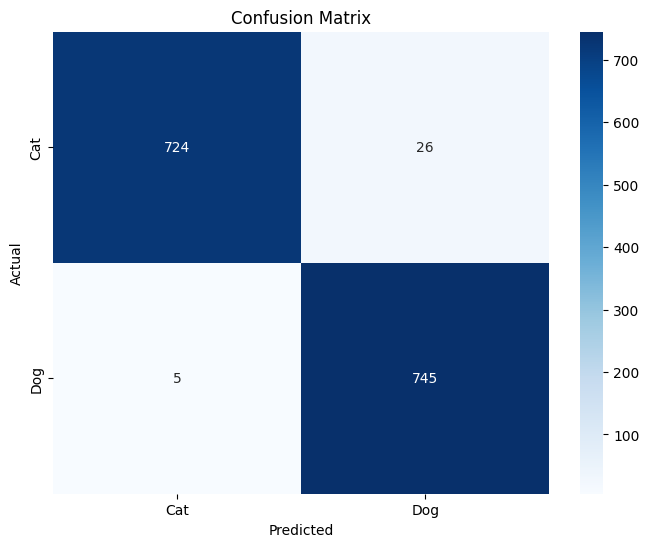

In [23]:
set_seed(seed=42)
best_model_transfer_learning = ResNetFinetuner.load_from_checkpoint(
    "/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/best-model-transfer-learning.ckpt",
    id2label=id2label,
    label2id=label2id
)

# Test
results = test_model(best_model_transfer_learning, test_dataloader, device)

Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([2, 512]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 24/24 [00:07<00:00,  3.09it/s]


Loss:       0.2478
Accuracy:   0.9100 (91.00%)
F1-Score:   0.9098
Precision:  0.9141
Recall:     0.9100
              precision    recall  f1-score   support

         Cat     0.9556    0.8600    0.9053       750
         Dog     0.8727    0.9600    0.9143       750

    accuracy                         0.9100      1500
   macro avg     0.9141    0.9100    0.9098      1500
weighted avg     0.9141    0.9100    0.9098      1500



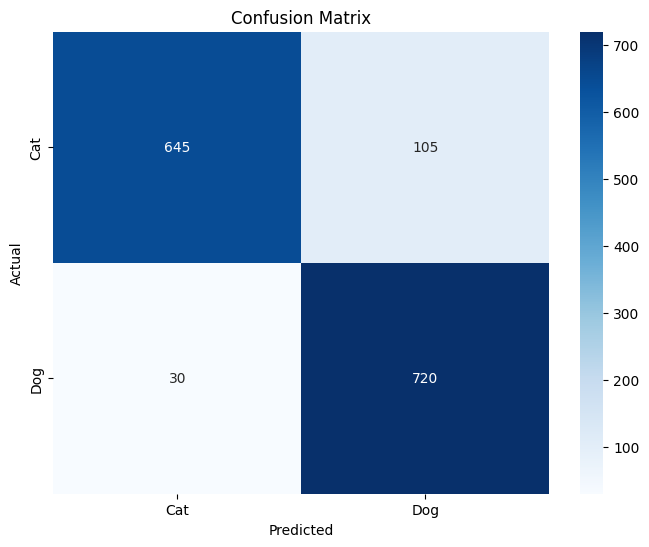

In [22]:
set_seed(seed=42)
best_model_full_finetuning = ResNetFinetuner.load_from_checkpoint(
    "/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/best-model-full-finetuning.ckpt",
    id2label=id2label,
    label2id=label2id
)

# Test
results = test_model(best_model_full_finetuning, test_dataloader, device)

## Inference

In [24]:
def inference(model, image_path, device='cuda'):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    transformed = val_transforms(image=image)
    pixel_values = transformed['image'].unsqueeze(0) 
    
    pixel_values = pixel_values.to(device)
    model = model.to(device)
    model.eval()
    
    # Inference
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        pred_class_id = probabilities.argmax(dim=1).item()
        confidence = probabilities[0][pred_class_id].item()
    
    predicted_label = id2label[pred_class_id]
    
    return predicted_label, confidence

In [25]:
inference(model=best_model_transfer_learning, 
         image_path="/kaggle/input/datasets/nguyenquan1123/dogs-cats-10k/test/dog/10023.jpg", 
         device=device)

('dog', 0.977895975112915)